# Registration of amyloid PET scans on MRI and MNI 152 template

## ============================================================================
## SECTION 1: Setup and Data Import
## ============================================================================

In [ ]:
## ============================================================================
## SECTION 1.1: Import Libraries
## ============================================================================
# All libraries are used:
# - numpy, pandas: data manipulation
# - os, fnmatch: file system operations
# - ants: neuroimaging operations (ANTsPy)
# - multiprocessing: parallel processing
# - time: timing operations
# - nibabel: NIfTI file I/O
import numpy as np 
import pandas as pd 
import os, fnmatch
import ants
from multiprocessing import Pool, cpu_count
import time
import nibabel as nib

In [ ]:
## ============================================================================
## SECTION 1.2: Import Additional Libraries
## ============================================================================
# Additional libraries for visualization and utilities
import pickle
import glob
import matplotlib.pyplot as plt
from datetime import datetime
import sys

In [ ]:
## OPTIONAL: Display options (not needed for pipeline)
pd.set_option('display.max_columns', 30)

In [ ]:
## UNUSED CODE: Old metadata file reference (commented out, not needed)
#meta = pd.read_csv('/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/metafile_completing/metafile_ADDLpipeline_abeta_mri_23_11_2023.csv')

In [ ]:
## ============================================================================
## SECTION 1.3: Load PET-MRI Pairs
## ============================================================================
# Load PET-MRI pairing table created by mri_processing notebook
pet_mri_pairs = pd.read_csv('/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/pet_mri_pairs.csv',header=[0], index_col=[0])
pet_mri_pairs.reset_index(drop=True, inplace = True)

In [ ]:
## ============================================================================
## SECTION 2: Load Templates
## ============================================================================
## SECTION 2.1: Load MNI Template
# Load MNI152 T1 template for registration
# Old template (commented out): 'mni_icbm152_t1_tal_nlin_sym_09a.nii'
mni_t1 = ants.image_read('/csc/epitkane/home/atagmazi/tpl-MNI152NLin6Asym_res-01_T1w.nii.gz')
#brain_mask = ants.image_read('/csc/epitkane/home/atagmazi/Downloads/mni_icbm152_nlin_sym_09a_nifti/mni_icbm152_nlin_sym_09a/mni_icbm152_t1_tal_nlin_sym_09a_mask.nii')


In [ ]:
## SECTION 2.2: Load Brain Mask (Optional)
# Load brain-extracted template (optional, for visualization)
m = ants.image_read('/csc/epitkane/home/atagmazi/tpl-MNI152NLin6Asym_res-01_desc-brain_T1w.nii.gz')


In [ ]:
## EXPLORATION CODE: Display brain mask image (not needed for pipeline)
# m

ANTsImage (LPI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (182, 218, 182)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (91.0, 126.0, -72.0)
	 Direction  : [-1.  0.  0.  0. -1.  0.  0.  0.  1.]

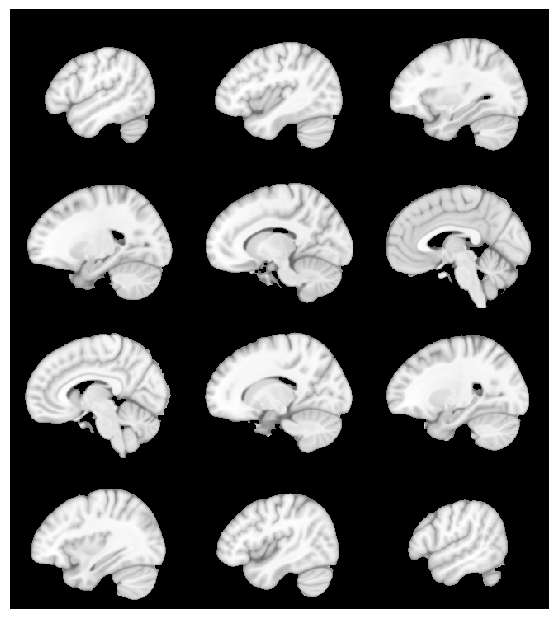

In [ ]:
## VISUALIZATION CODE: Plot brain mask (not needed for pipeline)
# ants.plot(m)

In [ ]:
## EXPLORATION CODE: Display mni_t1 image (not needed for pipeline)
# mni_t1

ANTsImage (LPI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (182, 218, 182)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (91.0, 126.0, -72.0)
	 Direction  : [-1.  0.  0.  0. -1.  0.  0.  0.  1.]

In [ ]:
## EXPLORATION CODE: Check template dimensions (not needed for pipeline)
# mni_t1.shape

(182, 218, 182)

In [ ]:
## UNUSED CODE: Reset indexes (commented out, not needed)
#reset indexes after removing rows
#pet_mri_pairs = pet_mri_pairs.reset_index(drop=True)

In [ ]:
## ============================================================================
## SECTION 3: Define Registration Function
## ============================================================================
# Register PET scans to MNI152 template via MRI
# For multi-frame PET: register frames to averaged template, then to MRI, then to MNI
# For single-frame PET: register directly to MRI, then to MNI
# Process:
#   1. Handle multi-frame PET (average frames, register frames to average)
#   2. Register PET to MRI (rigid)
#   3. Register MRI to MNI (affine) - uses pre-registered MRI
#   4. Apply combined transformations
#   5. Save registered PET scan
def registration(pet_mri_table):
    wrap_pet_all = dict()
    failed_toregister = []
    isnan = []
    #for i in range(2):
    for i in range(pet_mri_table.shape[0]):
        print(f"Processing sample {pet_mri_table['Image.Data.ID'].values[i]}") 
        #i = -i
        pet = ants.image_read(pet_mri_table['PATH'].values[i],reorient=True) # ask why there were 4 dimensions at the beginning
        mri = ants.image_read(pet_mri_table['MRI_PATH'].values[i])
        
        if len(pet.shape)>3:
            #print('start coreg pet to average pet template')
            # average all frames
            pet_template = np.mean([pet[:,:,:,0],pet[:,:,:,1],pet[:,:,:,2],pet[:,:,:,3]], axis = 0) 
            # shape (128, 128, 47)
            direction = [[-1.,  0.,  0.],[ 0., -1.,  0.],[ 0.,  0.,  1.]]

            #transfer numpy to ants image format for registration
            pet_template = ants.from_numpy(pet_template, origin = pet.origin[:3], spacing=pet.spacing[:3],direction=direction)
            pet0 = ants.from_numpy(pet[:,:,:,0], origin = pet.origin[:3], spacing=pet.spacing[:3],direction=direction)
            pet1 = ants.from_numpy(pet[:,:,:,1], origin = pet.origin[:3], spacing=pet.spacing[:3],direction=direction)
            pet2 = ants.from_numpy(pet[:,:,:,2], origin = pet.origin[:3], spacing=pet.spacing[:3],direction=direction)
            pet3 = ants.from_numpy(pet[:,:,:,3], origin = pet.origin[:3], spacing=pet.spacing[:3],direction=direction)

            # register each frame to averaged pet template
            pet_to_ptemplate0 = ants.registration(fixed=pet_template, moving=pet0, type_of_transform = 'Rigid')
            wrap_pet0 = ants.apply_transforms(fixed = pet_template, moving = pet0, transformlist=pet_to_ptemplate0[ 'fwdtransforms'])

            pet_to_ptemplate1 = ants.registration(fixed=pet_template, moving=pet1, type_of_transform = 'Rigid')
            wrap_pet1 = ants.apply_transforms(fixed = pet_template, moving = pet1, transformlist=pet_to_ptemplate1[ 'fwdtransforms'])

            pet_to_ptemplate2 = ants.registration(fixed=pet_template, moving=pet2, type_of_transform = 'Rigid')
            wrap_pet2 = ants.apply_transforms(fixed = pet_template, moving = pet2, transformlist=pet_to_ptemplate2[ 'fwdtransforms'])

            pet_to_ptemplate3 = ants.registration(fixed=pet_template, moving=pet3, type_of_transform = 'Rigid')
            wrap_pet3 = ants.apply_transforms(fixed = pet_template, moving = pet3, transformlist=pet_to_ptemplate3[ 'fwdtransforms'])

            # average registered frames
            pet_final = np.mean([wrap_pet0.numpy(),wrap_pet1.numpy(),wrap_pet2.numpy(),wrap_pet3.numpy()], axis = 0)
                
            pet = ants.from_numpy(pet_final, origin = pet.origin[:3], spacing=pet.spacing[:3],direction=direction)

            for filename in fnmatch.filter(os.listdir('/tmp/'), 'tmp*Warp.nii.gz')+fnmatch.filter(os.listdir('/tmp/'), '*Affine.mat'):
                os.remove(os.path.join('/tmp/', filename))
            
            #print('end coreg pet to average pet template')


        try:
            #print('start coreg pet to mri')
            pet_resampled = ants.resample_image(pet,(1, 1, 1), use_voxels=False,interp_type=0) #transfer all scans to one spacing (1x1x1)
            mri_resampled = ants.resample_image(mri,(1, 1, 1), use_voxels=False,interp_type=0)
            
            pet_to_mri = ants.registration(fixed=mri_resampled, moving=pet_resampled, type_of_transform = 'Affine', outprefix = pet_mri_table['Image.Data.ID'].values[i]+ 'pettomri') #'/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/registration/tmp/%s' % pet_mri_table['Image.Data.ID'].values[i])

            mri_to_mni = ants.registration(fixed=mni_t1, moving=mri_resampled, type_of_transform = 'Affine', outprefix= pet_mri_table['Image.Data.ID'].values[i]+ 'mritomni') # '/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/registration/tmp/%s' % pet_mri_table['Image.Data.ID'].values[i])

            transf_list = mri_to_mni[ 'fwdtransforms'] + pet_to_mri[ 'fwdtransforms']

            wrap_pet = ants.apply_transforms(fixed = mni_t1, moving = pet, transformlist=transf_list)
            
            if np.isnan(wrap_pet.numpy()).any():
                isnan.append(pet_mri_table['Image.Data.ID'].values[i])
                
            ants.image_write(wrap_pet,'/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_pet/'+pet_mri_table['Image.Data.ID'].values[i]+'_registered.nii')
            #wrap_pet_all[pet_mri_table['Image.Data.ID'].values[i]] = wrap_pet.numpy()

            print(str(i) + ' '+ pet_mri_table['Image.Data.ID'].values[i]+' done')

        #remove temporaly files from /tmp directory
            directory = '/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/registration/'
            # Ensure that pet_mri_pairs['Image.Data.ID'].values[i] is a string
            pattern = str(pet_mri_pairs['Image.Data.ID'].values[i]) + '*'

            # Match files using the pattern
            for filename in fnmatch.filter(os.listdir(directory), pattern):
                file_path = os.path.join(directory, filename)
                os.remove(file_path)
            
            #print('end coreg pet to mri')
                
        except:
            failed_toregister.append(pet_mri_table['Image.Data.ID'].values[i])
            print(str(i) + ' '+ pet_mri_table['Image.Data.ID'].values[i]+' failed')
            pass
        
        sys.stdout.flush()
    
    array = np.array(failed_toregister)
    array2 = np.array(isnan)
    # Get the current date and time
    now = datetime.now()

    # Format the date and time
    timestamp = now.strftime("%Y%m%d_%H%M%S")  # Format: YYYYMMDD_HHMMSS

    # Create a filename with the timestamp
    filename = f"PET_failed_toregister_{timestamp}.npy"
    filename2 = f"PET_isnan_{timestamp}.npy"


    # Save as a .npy file
    np.save(filename, array)
    np.save(filename2, array2)
    
    
    #return(wrap_pet_all)
    
    

In [ ]:

def split_data(data, chunk_size):
    """Splits data into chunks of size `chunk_size`."""
    return [data[i:i + chunk_size] for i in range(0, len(data), chunk_size)]

if __name__ == '__main__':
    
    chunk_size = 500  # Define the size of each chunk

    # Split the data
    splitted_data = split_data(pet_mri_pairs, chunk_size)

    # Start multiprocessing
    start_time = time.perf_counter()

    with Pool(processes=10) as pool:
        try:
            # Map the function across the data chunks
            results = pool.map(registration, splitted_data)
        except Exception as e:
            print(f"Error during multiprocessing: {e}")
            results = []  # Set to empty list if errors occur
        finally:
            pool.close()
            pool.join()  # Ensure all processes terminate properly

    # End timing
    finish_time = time.perf_counter()
    print(f"Program finished in {finish_time - start_time:.2f} seconds - using multiprocessing")
    print("---")


In [ ]:
sys.exit()